# Método Direto: Injeção da Trajetória no BEV Embedding

Em vez de passar a trajetória como uma "5ª câmera" pelo EfficientNet, codificamos
os 5 waypoints mais próximos com uma MLP e injetamos o resultado diretamente no
prior do BEV **antes** do cross-view attention.

```
traj (B, 10)
    │
    ▼  reshape + ×100
waypoints (B, 5, 2)   ← 5 waypoints × (x_frente, y_lateral) em metros
    │
    ▼  MLP por waypoint
feats (B, 5, 128)     ← um vetor de 128 dims para cada waypoint
    │
    ▼  Gaussiana 2D centrada na posição de cada waypoint no grid BEV
signal (B, 128, 32, 32)   ← sinal espacial somado sobre os 5 waypoints
    │
    ▼  soma com o prior
x (B, 128, 32, 32)    ← BEV prior enriquecido com informação de rota
    │
    ▼  cross-view attention com 4 câmeras RGB (n=4, sem 5ª câmera)
BEV gerado (B, 3, 192, 192)
```

## Passo 0 — Constantes e dados

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from einops import rearrange, repeat

# ── Constantes do CVT_3chL1Generator (fixas pela arquitetura) ──────────────
DIM          = 128   # dimensão do encoder (dim= no Encoder)
BEV_H        = 256   # bev_height no BEVEmbedding
BEV_W        = 256   # bev_width  no BEVEmbedding
H_METERS     = 100.0 # h_meters: quantos metros o BEV cobre em altura
W_METERS     = 100.0 # w_meters: quantos metros o BEV cobre em largura
DECODER_BLKS = 3     # len([128, 128, 64]) — cada bloco faz ×2 de upsample
H_PRIOR      = BEV_H // (2 ** DECODER_BLKS)  # = 32
W_PRIOR      = BEV_W // (2 ** DECODER_BLKS)  # = 32
N_WAYPOINTS  = 5     # os 5 waypoints mais próximos do traj vector
CELL_M       = H_METERS / H_PRIOR             # = 3.125 m por célula do grid

print("=== Dimensões do BEV prior ===")
print(f"  BEV H×W em pixels : {BEV_H}×{BEV_W}")
print(f"  BEV H×W em metros : {H_METERS:.0f}×{W_METERS:.0f}")
print(f"  Prior (antes do decoder): ({DIM}, {H_PRIOR}, {W_PRIOR})")
print(f"  Resolução do grid : {CELL_M:.3f} m/célula")
print()

# ── Dados do episode.json (como o ExpertDataset carrega) ───────────────────
ep_path = 'expert-data/route_00/ep_00/episode.json'
df = pd.read_json(ep_path)
step = 10
traj_raw = np.array(df.iloc[step]['traj'])   # shape (10,)

print("=== Vetor traj do episode.json ===")
print(f"  shape : {traj_raw.shape}   ← (N_WAYPOINTS × 2) = (5 × 2)")
print(f"  unidade: metros/100  (data_collect divide por 100 em process_obs)")
print(f"  valores: {np.round(traj_raw, 4)}")
print()

B = 4  # batch size de exemplo
traj_batch = torch.tensor(
    np.tile(traj_raw, (B, 1)), dtype=torch.float32
)  # (B, 10)
print(f"  traj como tensor de batch: {traj_batch.shape}  →  (B, 10)")

=== Dimensões do BEV prior ===
  BEV H×W em pixels : 256×256
  BEV H×W em metros : 100×100
  Prior (antes do decoder): (128, 32, 32)
  Resolução do grid : 3.125 m/célula

=== Vetor traj do episode.json ===
  shape : (10,)   ← (N_WAYPOINTS × 2) = (5 × 2)
  unidade: metros/100  (data_collect divide por 100 em process_obs)
  valores: [ 0.0053 -0.0054  0.1782 -0.0052  0.3183 -0.1362  0.3185 -0.6562  0.3187
 -1.1762]

  traj como tensor de batch: torch.Size([4, 10])  →  (B, 10)


## Passo 1 — Reshape e conversão para metros

`traj (B, 10)` → `waypoints (B, 5, 2)` em metros

In [2]:
# traj_batch : (B, 10)  — valores em metros/100

wp_m = traj_batch.view(B, N_WAYPOINTS, 2) * 100.0   # (B, 5, 2) em metros

print("=== Passo 1: traj → waypoints em metros ===")
print(f"  entrada : {traj_batch.shape}  →  (B, 10)")
print(f"  reshape : traj.view(B, {N_WAYPOINTS}, 2) × 100")
print(f"  saída   : {wp_m.shape}  →  (B, N_waypoints, 2)")
print()
print(f"  Waypoints do batch[0] (frame do ego, em metros):")
print(f"  {'idx':>3}  {'x_frente':>10}  {'y_lateral':>10}  {'dist':>8}  {'no BEV?':>8}")
for i in range(N_WAYPOINTS):
    wx = wp_m[0, i, 0].item()
    wy = wp_m[0, i, 1].item()
    dist = (wx**2 + wy**2)**0.5
    in_bev = abs(wx) <= H_METERS/2 and abs(wy) <= W_METERS/2
    print(f"  {i:>3}  {wx:>10.2f}m  {wy:>10.2f}m  {dist:>7.2f}m  {'✓' if in_bev else '✗ (fora)':>8}")
print()
print("  Os waypoints já vêm ordenados por proximidade (planejador de rota).")
print("  Waypoints fora do range ±50m → Gaussiana não atinge nenhuma célula do grid.")

=== Passo 1: traj → waypoints em metros ===
  entrada : torch.Size([4, 10])  →  (B, 10)
  reshape : traj.view(B, 5, 2) × 100
  saída   : torch.Size([4, 5, 2])  →  (B, N_waypoints, 2)

  Waypoints do batch[0] (frame do ego, em metros):
  idx    x_frente   y_lateral      dist   no BEV?
    0        0.53m       -0.54m     0.75m         ✓
    1       17.82m       -0.52m    17.83m         ✓
    2       31.83m      -13.62m    34.62m         ✓
    3       31.85m      -65.62m    72.94m  ✗ (fora)
    4       31.87m     -117.62m   121.86m  ✗ (fora)

  Os waypoints já vêm ordenados por proximidade (planejador de rota).
  Waypoints fora do range ±50m → Gaussiana não atinge nenhuma célula do grid.


## Passo 2 — MLP por waypoint

`waypoints (B, 5, 2)` → `feats (B, 5, 128)`

Aplicamos a mesma MLP independentemente a cada um dos 5 waypoints.

In [3]:
class WaypointMLP(nn.Module):
    """MLP aplicada per-waypoint: (2,) → (DIM,)."""
    def __init__(self, in_dim=2, hidden=64, out_dim=DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),   # (2,) → (64,)
            nn.ReLU(),
            nn.Linear(hidden, out_dim),  # (64,) → (128,)
        )
    def forward(self, wp):
        return self.net(wp)

mlp = WaypointMLP()

print("=== Passo 2: MLP por waypoint ===")
print(f"  Arquitetura: Linear(2, 64) → ReLU → Linear(64, {DIM})")
print(f"  Parâmetros : {sum(p.numel() for p in mlp.parameters()):,}")
print(f"  (EfficientNet-b4 tem ~19.3M — a MLP é 2270× menor)")
print()

wp_flat    = wp_m.view(-1, 2)                   # (B×5, 2)  ← flatten: processa todos de uma vez
feats_flat = mlp(wp_flat)                        # (B×5, 128)
feats      = feats_flat.view(B, N_WAYPOINTS, DIM)# (B, 5, 128)

print(f"  Fluxo de dimensões:")
print(f"    wp_m         {wp_m.shape}      →  (B, 5, 2)")
print(f"    view(-1, 2)  {wp_flat.shape}   →  (B×5, 2)   ← flatten para a MLP")
print(f"    MLP(·)       {feats_flat.shape} →  (B×5, {DIM})")
print(f"    view(B,5,·)  {feats.shape} →  (B, 5, {DIM})  ← um vetor por waypoint")

=== Passo 2: MLP por waypoint ===
  Arquitetura: Linear(2, 64) → ReLU → Linear(64, 128)
  Parâmetros : 8,512
  (EfficientNet-b4 tem ~19.3M — a MLP é 2270× menor)

  Fluxo de dimensões:
    wp_m         torch.Size([4, 5, 2])      →  (B, 5, 2)
    view(-1, 2)  torch.Size([20, 2])   →  (B×5, 2)   ← flatten para a MLP
    MLP(·)       torch.Size([20, 128]) →  (B×5, 128)
    view(B,5,·)  torch.Size([4, 5, 128]) →  (B, 5, 128)  ← um vetor por waypoint


## Passo 3 — Grid BEV e Gaussiana 2D

`feats (B, 5, 128)` + `grid (2, 32, 32)` → `gaussians (B, 5, 32, 32)`

Para cada waypoint `i`, a Gaussiana 2D mede o quão perto cada célula BEV está desse waypoint.

### Qual σ usar?

Resolução do grid: **3.125 m/célula** (100m ÷ 32 células).

| σ | células ativadas (>5%) | observação |
|---|---|---|
| 2m | ~5 por eixo | muito pontual, waypoint pode cair entre células |
| **6m** | **~11 por eixo** | **≈ 2 células/σ — especificidade sem ser pontual** |
| 10m | ~17 por eixo | difuso, perde localização espacial |

**Recomendado: σ = 6m**

In [15]:
SIGMA_M = 6.0  # σ em metros (≈ 2 × resolução de célula)

def build_bev_grid(h=H_PRIOR, w=W_PRIOR, bev_h=BEV_H, bev_w=BEV_W,
                   h_meters=H_METERS, w_meters=W_METERS):
    """Reproduz self.grid do BEVEmbedding: coordenadas em metros no frame do ego."""
    xs = torch.linspace(0, 1, w) * bev_w
    ys = torch.linspace(0, 1, h) * bev_h
    grid = torch.stack(torch.meshgrid(xs, ys, indexing='xy'), 0)
    grid = nn.functional.pad(grid, (0,0,0,0,0,1), value=1)
    sh, sw = bev_h / h_meters, bev_w / w_meters
    V = torch.tensor([[0., -sw, bev_w/2.], [-sh, 0., bev_h/2.], [0., 0., 1.]])
    V_inv = V.inverse()
    grid = V_inv @ rearrange(grid, 'd h w -> d (h w)')
    grid = rearrange(grid, 'd (h w) -> d h w', h=h, w=w)
    return grid[:2]   # (2, H_PRIOR, W_PRIOR) em metros

grid = build_bev_grid()  # (2, 32, 32)
gx   = grid[0]           # (32, 32)  x_ego em metros (frente/trás)
gy   = grid[1]           # (32, 32)  y_ego em metros (lateral)

print("=== Passo 3: grid BEV ===")
print(f"  grid shape          : {grid.shape}  →  (2, H_PRIOR, W_PRIOR)")
print(f"  gx (x_frente) range : [{gx.min():.0f}m, {gx.max():.0f}m]")
print(f"  gy (y_lateral) range: [{gy.min():.0f}m, {gy.max():.0f}m]")
print(f"  resolução           : {CELL_M:.3f} m/célula")
print(f"  σ = {SIGMA_M}m  →  {SIGMA_M/CELL_M:.1f} células/σ")
print()

# Calcula as 5 Gaussianas (batch[0] para ilustrar)
print("  Gaussianas para batch[0]:")
print(f"  {'wp':>3}  {'pos (m)':>18}  {'pico':>6}  {'células >5%':>12}")
for i in range(N_WAYPOINTS):
    wx_i = wp_m[0, i, 0].item()
    wy_i = wp_m[0, i, 1].item()
    dist_sq_i = (gx - wx_i)**2 + (gy - wy_i)**2
    g_i = torch.exp(-dist_sq_i / (2 * SIGMA_M**2))
    n_active = (g_i > 0.05).sum().item()
    print(f"  {i:>3}  ({wx_i:>7.2f}m, {wy_i:>7.2f}m)  {g_i.max():.4f}  {n_active:>5}/{H_PRIOR*W_PRIOR}")

=== Passo 3: grid BEV ===
  grid shape          : torch.Size([2, 32, 32])  →  (2, H_PRIOR, W_PRIOR)
  gx (x_frente) range : [-50m, 50m]
  gy (y_lateral) range: [-50m, 50m]
  resolução           : 3.125 m/célula
  σ = 6.0m  →  1.9 células/σ

  Gaussianas para batch[0]:
   wp             pos (m)    pico   células >5%
    0  (   0.53m,   -0.54m)  0.9681     66/1024
    1  (  17.82m,   -0.52m)  0.9834     65/1024
    2  (  31.83m,  -13.62m)  0.9699     65/1024
    3  (  31.85m,  -65.62m)  0.0331      0/1024
    4  (  31.87m, -117.62m)  0.0000      0/1024


## Passo 4 — Montar o sinal e injetar no BEV prior

`feats (B, 5, 128)` × `gaussians (B, 5, 32, 32)` → `signal (B, 128, 32, 32)`

Para cada waypoint `i`: `contrib_i = feat_i[:, :, None, None] × gaussian_i[:, None]`  
Soma sobre os 5 → `signal`. Depois: `x = bev_prior + signal`.

In [16]:
signal = torch.zeros(B, DIM, H_PRIOR, W_PRIOR)

print("=== Passo 4: acumulação do sinal ===")
print(f"  signal inicial : zeros {signal.shape}")
print()

for i in range(N_WAYPOINTS):
    wx = wp_m[:, i, 0]   # (B,)
    wy = wp_m[:, i, 1]   # (B,)

    dist_sq    = (gx[None] - wx[:, None, None])**2 + \
                 (gy[None] - wy[:, None, None])**2    # (B, 32, 32)
    gaussian_i = torch.exp(-dist_sq / (2 * SIGMA_M**2))  # (B, 32, 32)
    feat_i     = feats[:, i]                              # (B, 128)
    contrib    = feat_i[:, :, None, None] * gaussian_i[:, None]  # (B, 128, 32, 32)
    signal    += contrib

    print(f"  wp{i}: gaussian {tuple(gaussian_i.shape)}"
          f"  ×  feat {tuple(feat_i.shape)}"
          f"  →  contrib {tuple(contrib.shape)}"
          f"   pico={gaussian_i[0].max():.3f}")

print()
print(f"  signal final : {signal.shape}")
print()
print("=== Injeção no Encoder.forward (encoder.py:343-355) ===")
print()
print("  ANTES (sem trajetória):")
print("    x = self.bev_embedding.get_prior()       # (128, 32, 32)")
print("    x = repeat(x, '... -> b ...', b=b)       # (B, 128, 32, 32)")
print("    for cross_view, feature, layer in ...:   # n=5 câmeras (4 RGB + traj_plot)")
print()
print("  DEPOIS (injeção direta):")
print("    x = self.bev_embedding.get_prior()       # (128, 32, 32)")
print("    x = repeat(x, '... -> b ...', b=b)       # (B, 128, 32, 32)")
print("    signal = traj_to_bev_signal(             # (B, 128, 32, 32)")
print("                batch['traj'], mlp, grid, SIGMA_M)")
print("    x = x + signal                           # ← INJEÇÃO AQUI")
print("    for cross_view, feature, layer in ...:   # n=4 câmeras (só RGB)")

=== Passo 4: acumulação do sinal ===
  signal inicial : zeros torch.Size([4, 128, 32, 32])

  wp0: gaussian (4, 32, 32)  ×  feat (4, 128)  →  contrib (4, 128, 32, 32)   pico=0.968
  wp1: gaussian (4, 32, 32)  ×  feat (4, 128)  →  contrib (4, 128, 32, 32)   pico=0.983
  wp2: gaussian (4, 32, 32)  ×  feat (4, 128)  →  contrib (4, 128, 32, 32)   pico=0.970
  wp3: gaussian (4, 32, 32)  ×  feat (4, 128)  →  contrib (4, 128, 32, 32)   pico=0.033
  wp4: gaussian (4, 32, 32)  ×  feat (4, 128)  →  contrib (4, 128, 32, 32)   pico=0.000

  signal final : torch.Size([4, 128, 32, 32])

=== Injeção no Encoder.forward (encoder.py:343-355) ===

  ANTES (sem trajetória):
    x = self.bev_embedding.get_prior()       # (128, 32, 32)
    x = repeat(x, '... -> b ...', b=b)       # (B, 128, 32, 32)
    for cross_view, feature, layer in ...:   # n=5 câmeras (4 RGB + traj_plot)

  DEPOIS (injeção direta):
    x = self.bev_embedding.get_prior()       # (128, 32, 32)
    x = repeat(x, '... -> b ...', b=b)      

## Passo 5 — Visualização das Gaussianas no grid BEV

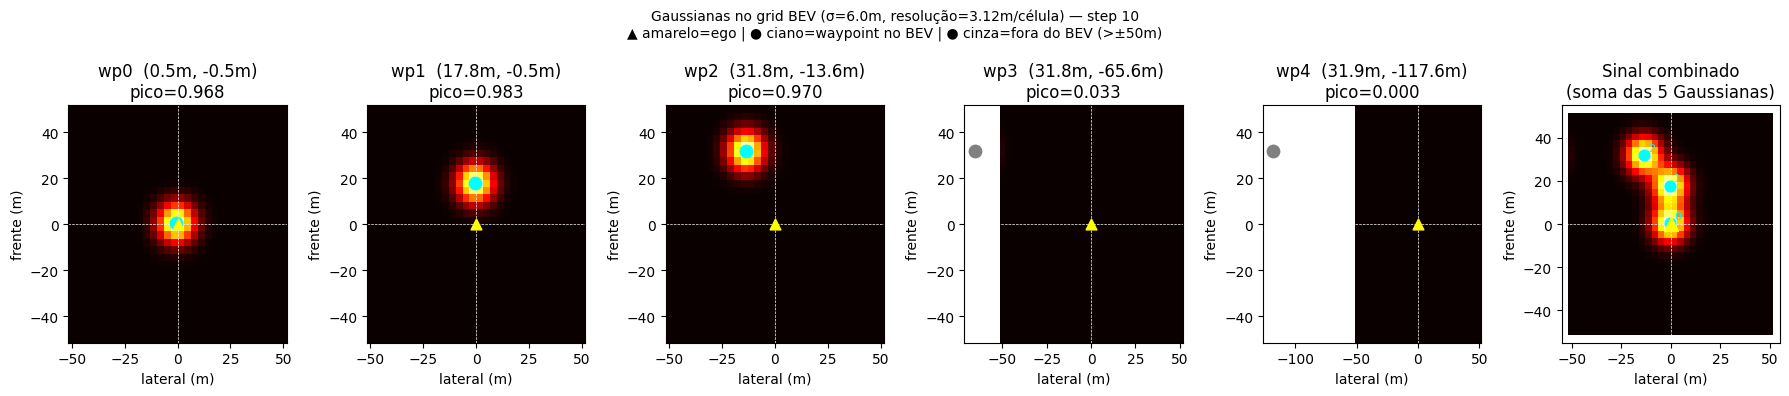

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

gx_np = gx.numpy()
gy_np = gy.numpy()
wp_np = wp_m[0].numpy()   # (5, 2) do batch[0]

gaussians_np = []
combined = np.zeros((H_PRIOR, W_PRIOR))
for i in range(N_WAYPOINTS):
    wx_i, wy_i = wp_np[i]
    d2 = (gx_np - wx_i)**2 + (gy_np - wy_i)**2
    g  = np.exp(-d2 / (2 * SIGMA_M**2))
    gaussians_np.append(g)
    combined += g

fig, axes = plt.subplots(1, N_WAYPOINTS + 1, figsize=(18, 4))

for i, (g, ax) in enumerate(zip(gaussians_np, axes)):
    wx_i, wy_i = wp_np[i]
    in_bev = abs(wx_i) <= H_METERS/2 and abs(wy_i) <= W_METERS/2
    ax.pcolormesh(gy_np, gx_np, g, cmap='hot', vmin=0, vmax=1, shading='auto')
    color = 'cyan' if in_bev else 'gray'
    ax.scatter([wy_i], [wx_i], c=color, s=80, zorder=5)
    ax.scatter([0], [0], c='yellow', marker='^', s=60, zorder=6)
    ax.set_title(f'wp{i}  ({wx_i:.1f}m, {wy_i:.1f}m)\npico={g.max():.3f}')
    ax.set_xlabel('lateral (m)')
    ax.set_ylabel('frente (m)')
    ax.axhline(0, color='white', lw=0.5, ls='--')
    ax.axvline(0, color='white', lw=0.5, ls='--')

ax = axes[-1]
ax.pcolormesh(gy_np, gx_np, np.clip(combined, 0, 1), cmap='hot', shading='auto')
for i, (wx_i, wy_i) in enumerate(wp_np):
    in_bev = abs(wx_i) <= H_METERS/2 and abs(wy_i) <= W_METERS/2
    ax.scatter([wy_i], [wx_i], c='cyan' if in_bev else 'gray', s=60, zorder=5)
    ax.annotate(str(i), (wy_i, wx_i), color='cyan' if in_bev else 'gray',
                fontsize=8, xytext=(3,3), textcoords='offset points')
ax.scatter([0], [0], c='yellow', marker='^', s=100, zorder=6)
ax.set_title('Sinal combinado\n(soma das 5 Gaussianas)')
ax.set_xlabel('lateral (m)')
ax.set_ylabel('frente (m)')
ax.axhline(0, color='white', lw=0.5, ls='--')
ax.axvline(0, color='white', lw=0.5, ls='--')
ax.set_xlim(-55, 55); ax.set_ylim(-55, 55)

plt.suptitle(
    f'Gaussianas no grid BEV (σ={SIGMA_M}m, resolução={CELL_M:.2f}m/célula) — step {step}\n'
    f'▲ amarelo=ego | ● ciano=waypoint no BEV | ● cinza=fora do BEV (>±50m)',
    fontsize=10
)
plt.tight_layout()
#plt.savefig('bev_traj_gaussians.png', dpi=120, bbox_inches='tight')
plt.show()
#print("Salvo em bev_traj_gaussians.png")